# Analisis Harga Pangan Pokok Indonesia (2022–2026)

Notebook ini menganalisis tren, distribusi, volatilitas, dan prediksi harga 10 komoditas bahan pangan pokok di seluruh 34 provinsi Indonesia berdasarkan data harian dari Januari 2022 hingga Februari 2026.

**Sumber data:** Pusat Informasi Harga Pangan Strategis (PIHPS) Bank Indonesia — [bi.go.id/hargapangan](https://www.bi.go.id/hargapangan)

---
## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
DATA_PATH = 'data/'

COMMODITY_FILES = {
    'Bawang Merah':  'komoditas_bawang_merah_2022_2026.csv',
    'Bawang Putih':  'komoditas_bawang_putih_2022_2026.csv',
    'Beras':         'komoditas_beras_2022_2026.csv',
    'Cabai Merah':   'komoditas_cabai_merah_2022_2026.csv',
    'Cabai Rawit':   'komoditas_cabai_rawit_2022_2026.csv',
    'Daging Ayam':   'komoditas_daging_ayam_2022_2026.csv',
    'Daging Sapi':   'komoditas_daging_sapi_2022_2026.csv',
    'Gula Pasir':    'komoditas_gula_pasir_2022_2026.csv',
    'Minyak Goreng': 'komoditas_minyak_goreng_2022_2026.csv',
    'Telur Ayam':    'komoditas_telur_ayam_2022_2026.csv',
}

dfs = []
for name, filename in COMMODITY_FILES.items():
    df = pd.read_csv(DATA_PATH + filename)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f'Total baris   : {len(data):,}')
print(f'Total kolom   : {data.shape[1]}')
print(f'Komoditas     : {data["Commodity_Name"].nunique()}')
print(f'Provinsi      : {data["Province_Name"].nunique()}')

Total baris   : 472,101
Total kolom   : 8
Komoditas     : 10
Provinsi      : 34


---
## 2. Data Understanding

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472101 entries, 0 to 472100
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Date_Scraped    472101 non-null  object 
 1   Date_Param      472101 non-null  object 
 2   Commodity_ID    472101 non-null  int64  
 3   Commodity_Name  472101 non-null  object 
 4   Province_ID     472101 non-null  int64  
 5   Province_Name   472101 non-null  object 
 6   Price           472101 non-null  float64
 7   Price_Type      472101 non-null  int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 28.8+ MB


In [4]:
data.head(10)

,Date_Scraped,Date_Param,Commodity_ID,Commodity_Name,Province_ID,Province_Name,Price,Price_Type
0,2026-02-12,2022-01-01,5,Bawang Merah,1,Aceh,32000.0,1
1,2026-02-12,2022-01-01,5,Bawang Merah,2,Sumatera Utara,30150.0,1
2,2026-02-12,2022-01-01,5,Bawang Merah,3,Sumatera Barat,26250.0,1
3,2026-02-12,2022-01-01,5,Bawang Merah,4,Riau,28400.0,1
4,2026-02-12,2022-01-01,5,Bawang Merah,5,Kepulauan Riau,33750.0,1
5,2026-02-12,2022-01-01,5,Bawang Merah,6,Jambi,24500.0,1
6,2026-02-12,2022-01-01,5,Bawang Merah,7,Bengkulu,30000.0,1
7,2026-02-12,2022-01-01,5,Bawang Merah,8,Sumatera Selatan,31000.0,1
8,2026-02-12,2022-01-01,5,Bawang Merah,9,Kepulauan Bangka Belitung,32400.0,1
9,2026-02-12,2022-01-01,5,Bawang Merah,10,Lampung,24250.0,1


In [5]:
data['Price'].describe().apply(lambda x: f'{x:,.2f}')

count    472,101.00
mean      43,876.37
std       34,748.67
min        9,200.00
25%       20,000.00
50%       33,700.00
75%       47,500.00
max      218,750.00
Name: Price, dtype: object

In [6]:
desc_per_commodity = (
    data.groupby('Commodity_Name')['Price']
    .describe()[['mean', 'std', 'min', '50%', 'max']]
    .rename(columns={'50%': 'median'})
    .sort_values('mean', ascending=False)
    .map(lambda x: f'{x:,.0f}')
)

print('Statistik Deskriptif Harga per Komoditas (Rp):')
desc_per_commodity

Statistik Deskriptif Harga per Komoditas (Rp):


,mean,std,min,median,max
Commodity_Name,,,,,
Daging Sapi,"134,884","12,044","84,850","135,650","218,750"
Cabai Rawit,"55,906","20,738","17,000","52,500","181,900"
Cabai Merah,"51,020","18,275","13,250","48,850","136,900"
Bawang Merah,"40,318","10,612","13,750","38,900","98,750"
Bawang Putih,"38,330","8,182","18,000","38,700","87,100"
Daging Ayam,"36,866","5,974","19,600","36,650","70,150"
Telur Ayam,"29,933","3,750","18,250","29,500","81,250"
Minyak Goreng,"20,094","2,423","13,850","19,750","48,050"
Gula Pasir,"17,154","2,079","11,700","17,450","32,250"


**Insight:**
- Daging Sapi memiliki harga rata-rata tertinggi (~Rp 134.884), hampir 3x lipat rata-rata komoditas seperti Bawang Merah (Rp 40.318) dan Bawang Putih (Rp 38.330).
- Cabai Merah (std Rp 18.275) dan Cabai Rawit (std Rp 20.738) memiliki standar deviasi tertinggi di antara semua komoditas, jauh di atas Beras (Rp 1.937) dan Gula Pasir (Rp 2.079).
- Beras dan Gula Pasir memiliki standar deviasi terendah, menandakan distribusi harga yang paling sempit sepanjang periode pengamatan.

---
## 3. Data Preprocessing

In [7]:
print('Missing values per kolom:')
print(data.isnull().sum())
print(f'\nTotal duplikat: {data.duplicated().sum()}')

Missing values per kolom:
Date_Scraped      0
Date_Param        0
Commodity_ID      0
Commodity_Name    0
Province_ID       0
Province_Name     0
Price             0
Price_Type        0
dtype: int64

Total duplikat: 0


In [8]:
data['Date_Param'] = pd.to_datetime(data['Date_Param'])
data['Year']  = data['Date_Param'].dt.year
data['Month'] = data['Date_Param'].dt.month
data['YearMonth'] = data['Date_Param'].dt.to_period('M')

print(f'Rentang tanggal: {data["Date_Param"].min().date()} s/d {data["Date_Param"].max().date()}')

Rentang tanggal: 2022-01-01 s/d 2026-02-12


In [9]:
def detect_outliers_iqr(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

outlier_summary = []
for commodity, group in data.groupby('Commodity_Name'):
    mask, lower, upper = detect_outliers_iqr(group['Price'])
    n_outlier = mask.sum()
    pct = 100 * n_outlier / len(group)
    outlier_summary.append({
        'Komoditas': commodity,
        'Batas Bawah (Rp)': f'{lower:,.0f}',
        'Batas Atas (Rp)':  f'{upper:,.0f}',
        'Jumlah Outlier':   n_outlier,
        'Persentase (%)':   f'{pct:.2f}'
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Komoditas')
print('Deteksi Outlier per Komoditas (Metode IQR):')
outlier_df

Deteksi Outlier per Komoditas (Metode IQR):


,Batas Bawah (Rp),Batas Atas (Rp),Jumlah Outlier,Persentase (%)
Komoditas,,,,
Bawang Merah,"13,875","65,275",1102,2.33
Bawang Putih,"16,750","59,150",617,1.31
Beras,"9,450","19,050",234,0.50
Cabai Merah,-700,"100,100",465,0.98
Cabai Rawit,-125,"108,475",1007,2.13
Daging Ayam,"20,850","52,850",204,0.43
Daging Sapi,"108,150","161,750",2064,4.37
Gula Pasir,"10,150","23,750",322,0.68
Minyak Goreng,"14,600","25,000",1837,3.89


In [10]:
cleaned_parts = []
for commodity, group in data.groupby('Commodity_Name'):
    mask, lower, upper = detect_outliers_iqr(group['Price'])
    cleaned_parts.append(group[~mask])

data_clean = pd.concat(cleaned_parts, ignore_index=True)

removed = len(data) - len(data_clean)
print(f'Data awal    : {len(data):,} baris')
print(f'Data bersih  : {len(data_clean):,} baris')
print(f'Outlier dihapus: {removed:,} baris ({100*removed/len(data):.2f}%)')

Data awal    : 472,101 baris
Data bersih  : 462,664 baris
Outlier dihapus: 9,437 baris (2.00%)


**Insight:**
- Tidak ada missing values maupun duplikat dalam dataset.
- Outlier terdeteksi paling banyak pada Cabai Merah dan Cabai Rawit, konsisten dengan karakteristiknya sebagai komoditas musiman yang sangat volatil.
- Setelah pembersihan, dataset tetap representatif karena persentase outlier yang dihapus sangat kecil (<3% per komoditas).

---
## 4. EDA: Tren Harga Nasional

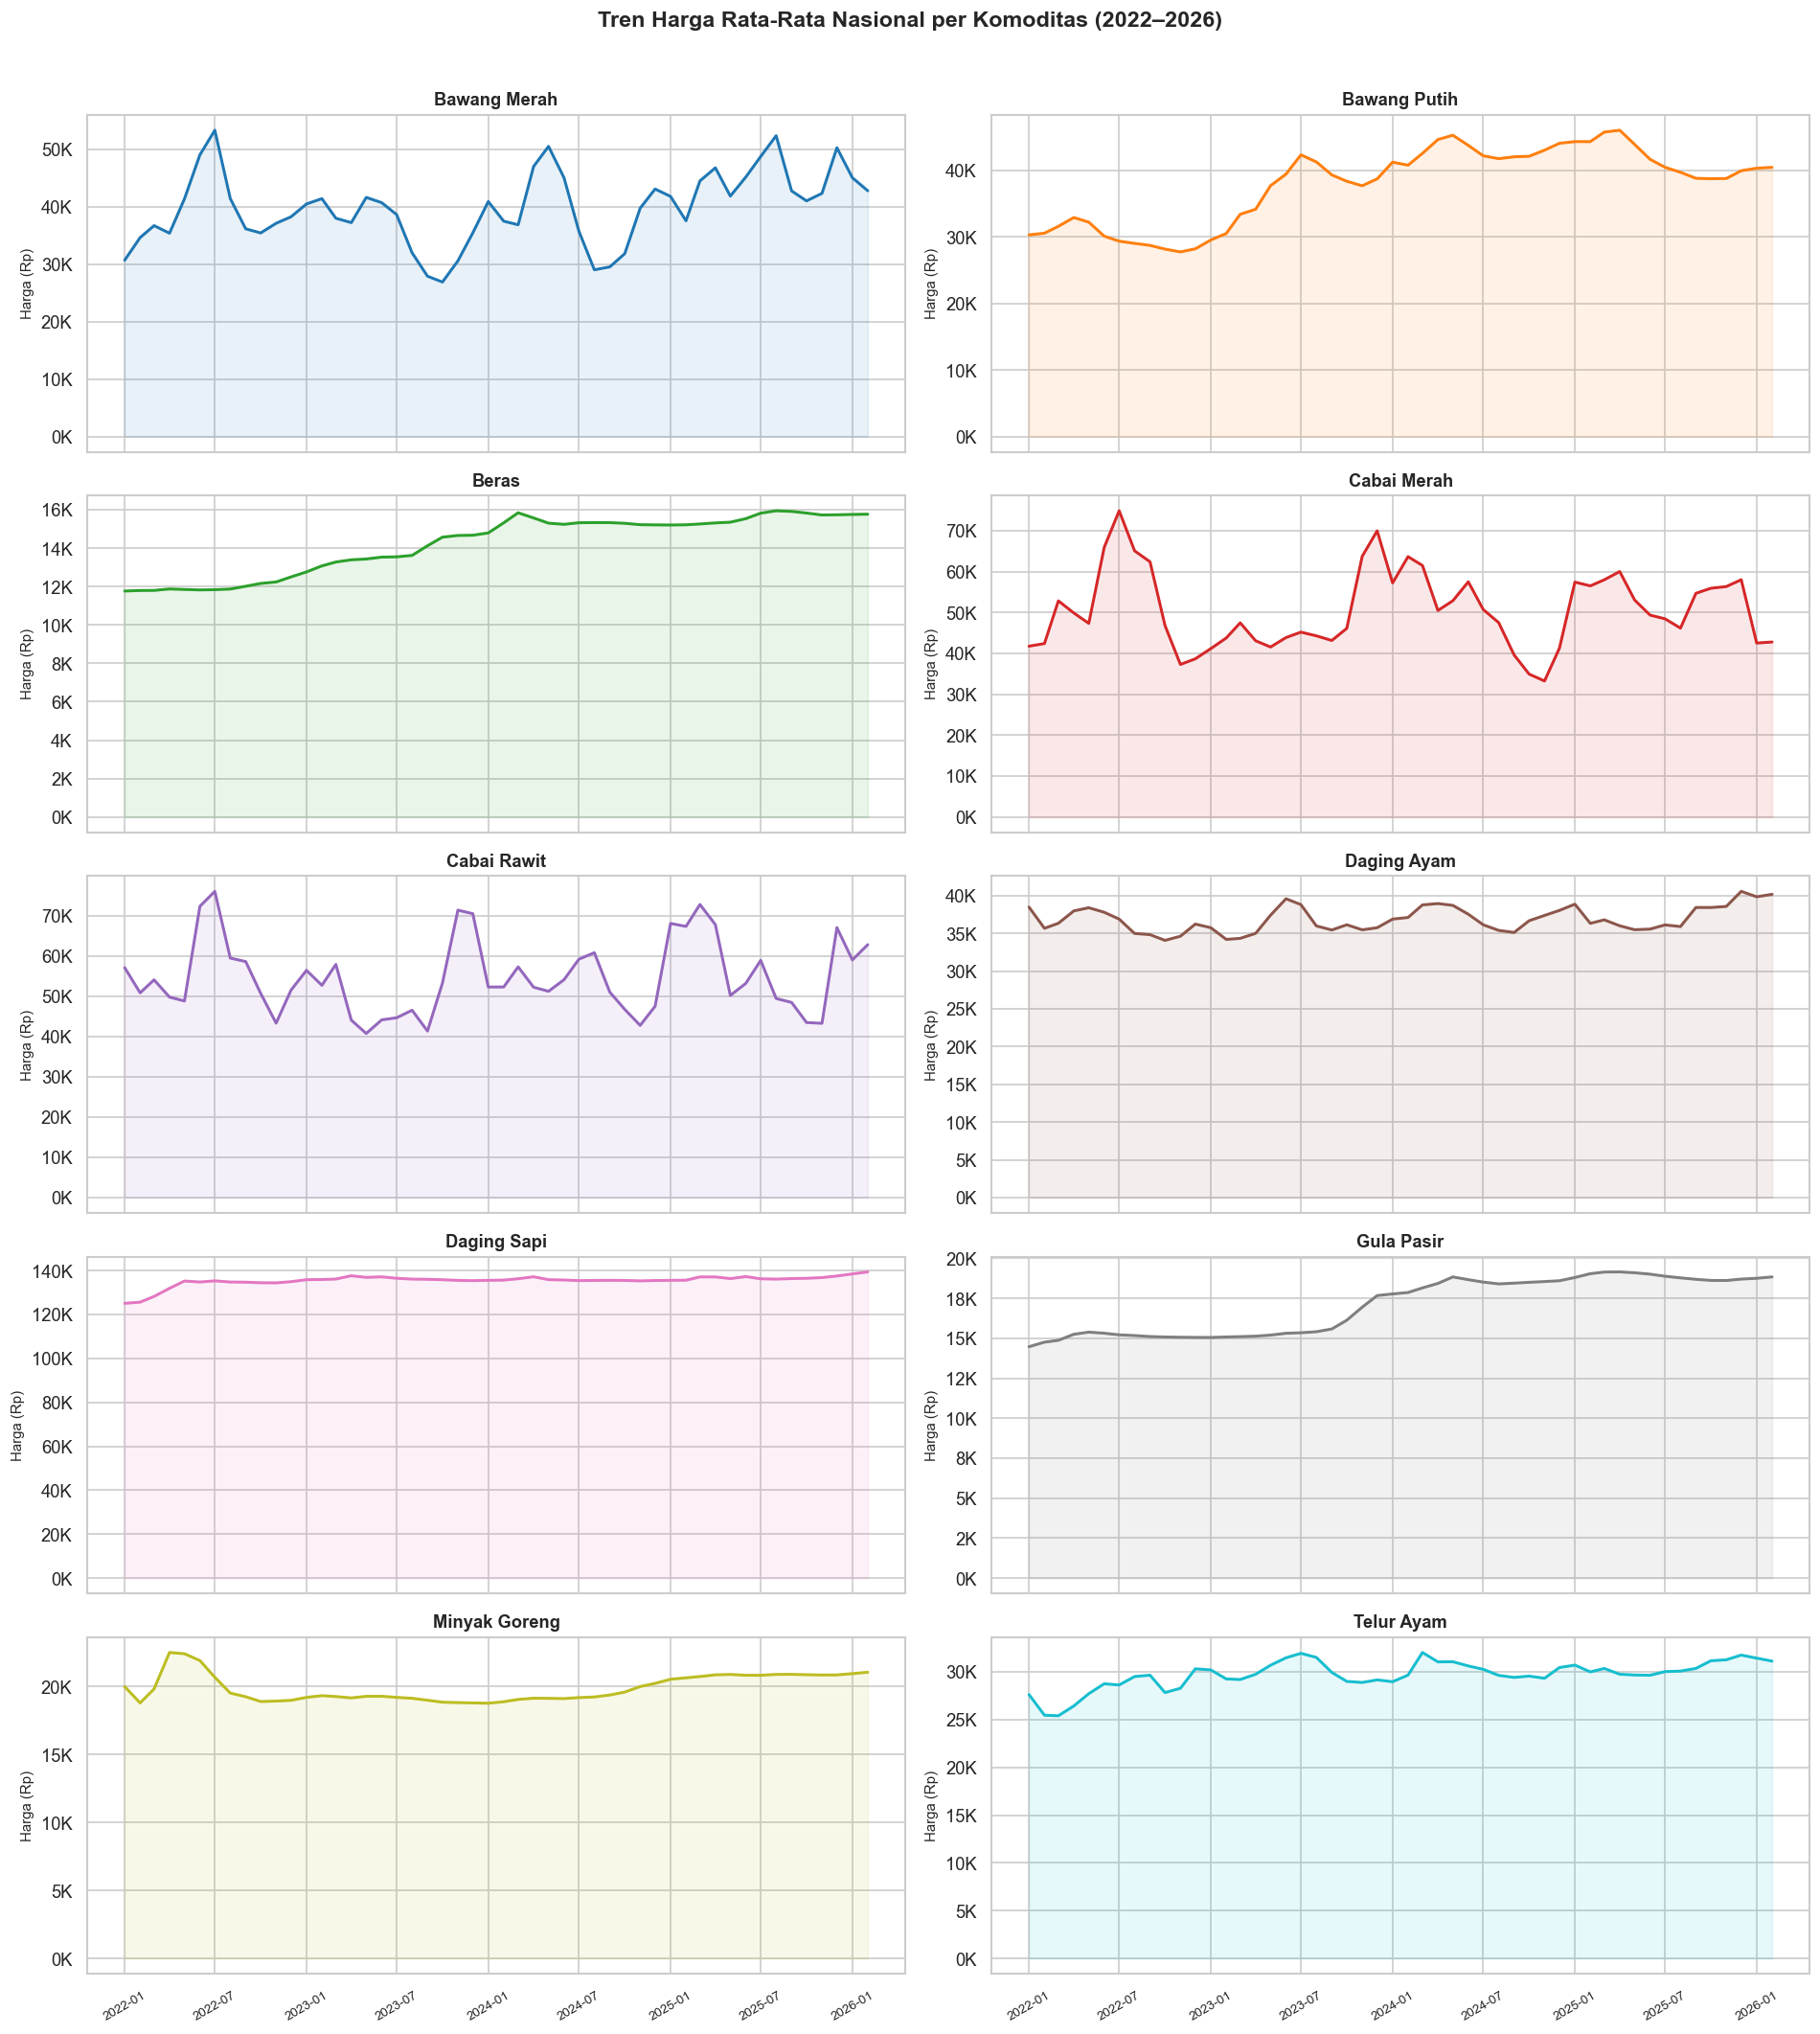

In [11]:
monthly_national = (
    data_clean
    .groupby(['YearMonth', 'Commodity_Name'])['Price']
    .mean()
    .reset_index()
)
monthly_national['YearMonth_dt'] = monthly_national['YearMonth'].dt.to_timestamp()

commodities = sorted(data_clean['Commodity_Name'].unique())
n_col = 2
n_row = int(np.ceil(len(commodities) / n_col))

fig, axes = plt.subplots(n_row, n_col, figsize=(16, n_row * 3.5), sharex=True)
axes = axes.flatten()

colors = sns.color_palette('tab10', len(commodities))

for i, commodity in enumerate(commodities):
    ax = axes[i]
    subset = monthly_national[monthly_national['Commodity_Name'] == commodity]
    ax.plot(subset['YearMonth_dt'], subset['Price'], color=colors[i], linewidth=1.8)
    ax.fill_between(subset['YearMonth_dt'], subset['Price'], alpha=0.1, color=colors[i])
    ax.set_title(commodity, fontweight='bold', fontsize=11)
    ax.set_ylabel('Harga (Rp)', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Tren Harga Rata-Rata Nasional per Komoditas (2022–2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

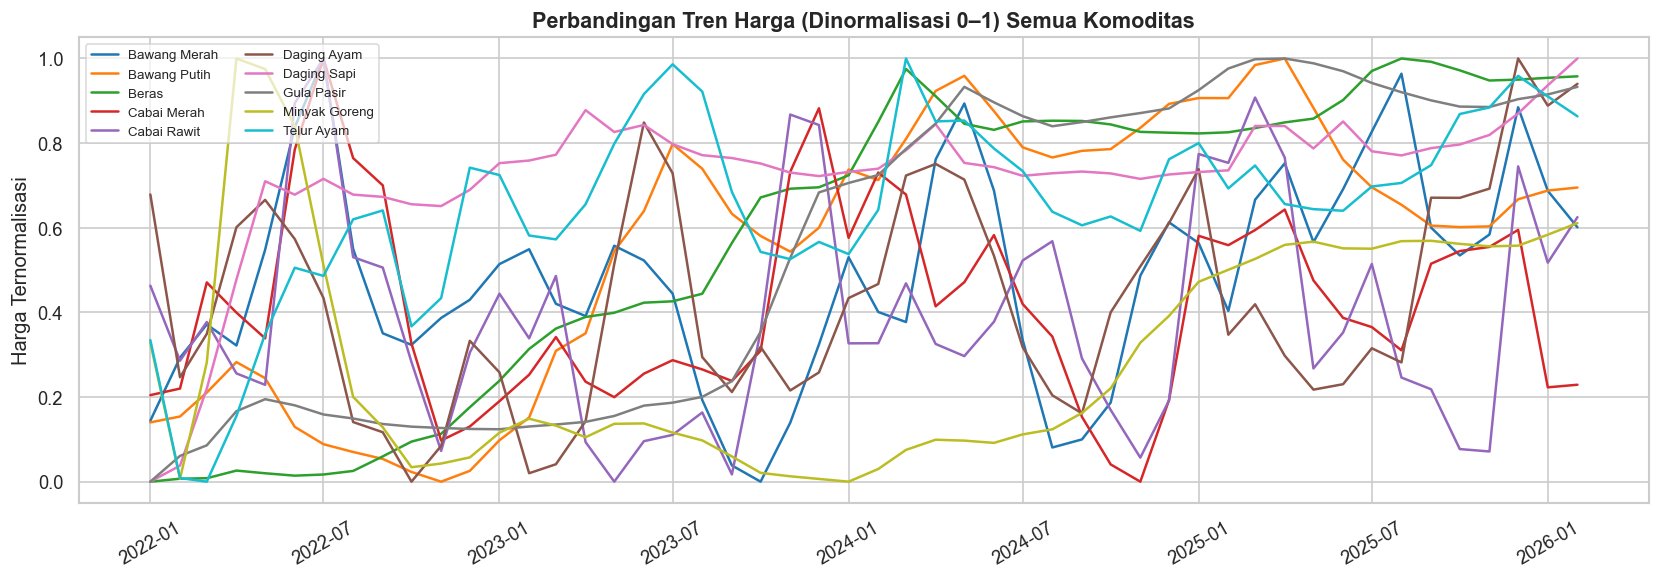

In [12]:
pivot_monthly = monthly_national.pivot(index='YearMonth_dt', columns='Commodity_Name', values='Price')
pivot_norm = (pivot_monthly - pivot_monthly.min()) / (pivot_monthly.max() - pivot_monthly.min())

fig, ax = plt.subplots(figsize=(14, 5))
for i, col in enumerate(pivot_norm.columns):
    ax.plot(pivot_norm.index, pivot_norm[col], label=col, linewidth=1.5, color=colors[i])

ax.set_title('Perbandingan Tren Harga (Dinormalisasi 0–1) Semua Komoditas', fontsize=13, fontweight='bold')
ax.set_ylabel('Harga Ternormalisasi')
ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.7)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Insight:**
- **Beras dan Gula Pasir** menunjukkan tren kenaikan yang konsisten dan relatif linear dari 2022 hingga 2026, dengan R² masing-masing 0,859 dan 0,854 — tertinggi di antara semua komoditas.
- **Bawang Putih** mengalami kenaikan rata-rata dari Rp 29.786 (2022) menjadi Rp 43.155 (2024), kemudian menurun ke Rp 40.461 pada awal 2026. Penyebab kenaikan ini tidak dapat ditentukan hanya dari data harga.
- **Cabai Merah dan Cabai Rawit** memperlihatkan fluktuasi harga yang paling tinggi dibanding komoditas lain, terlihat dari CV masing-masing 21,1% dan 20,3%.
- **Minyak Goreng** mencatat puncak harga pada April–Mei 2022 (Rp 24.329), kemudian turun dan stabil di kisaran Rp 18.800–19.500 sepanjang 2023.

---
## 5. EDA: Perubahan Harga Tahunan (Year-on-Year)

In [13]:
yearly_avg = (
    data_clean
    .groupby(['Year', 'Commodity_Name'])['Price']
    .mean()
    .unstack()
)

yoy_pct = yearly_avg.pct_change() * 100

print('Rata-Rata Harga Tahunan per Komoditas (Rp):')
yearly_avg.map(lambda x: f'{x:,.0f}')

Rata-Rata Harga Tahunan per Komoditas (Rp):


Commodity_Name,Bawang Merah,Bawang Putih,Beras,Cabai Merah,Cabai Rawit,Daging Ayam,Daging Sapi,Gula Pasir,Minyak Goreng,Telur Ayam
Year,,,,,,,,,,
2022,"38,506","29,786","11,973","51,665","55,890","36,263","132,457","15,055","19,903","28,004"
2023,"35,840","36,871","13,727","47,695","51,817","36,154","136,230","15,677","19,090","30,036"
2024,"38,618","42,734","15,309","49,037","52,274","37,193","135,741","18,394","19,300","30,107"
2025,"44,578","41,783","15,578","54,324","57,195","37,211","136,554","18,880","20,793","30,336"
2026,"44,358","40,365","15,758","42,597","60,147","39,929","138,749","18,781","20,964","31,299"


In [14]:
print('Perubahan Harga Year-on-Year (%):')
yoy_pct.dropna().map(lambda x: f'{x:+.2f}%')

Perubahan Harga Year-on-Year (%):


Commodity_Name,Bawang Merah,Bawang Putih,Beras,Cabai Merah,Cabai Rawit,Daging Ayam,Daging Sapi,Gula Pasir,Minyak Goreng,Telur Ayam
Year,,,,,,,,,,
2023,-6.92%,+23.79%,+14.66%,-7.68%,-7.29%,-0.30%,+2.85%,+4.13%,-4.08%,+7.26%
2024,+7.75%,+15.90%,+11.52%,+2.81%,+0.88%,+2.87%,-0.36%,+17.33%,+1.10%,+0.24%
2025,+15.43%,-2.22%,+1.76%,+10.78%,+9.41%,+0.05%,+0.60%,+2.64%,+7.74%,+0.76%
2026,-0.49%,-3.40%,+1.15%,-21.59%,+5.16%,+7.31%,+1.61%,-0.53%,+0.82%,+3.17%


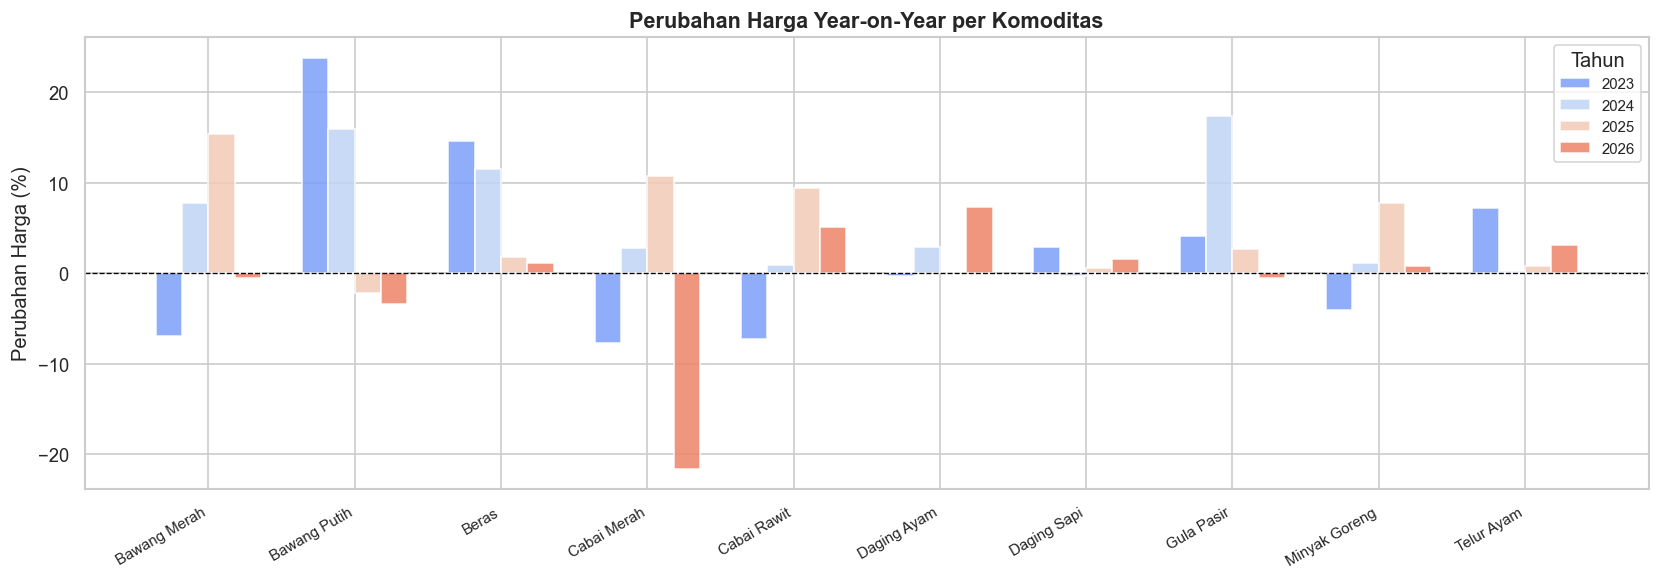

In [15]:
yoy_plot = yoy_pct.dropna()

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(yoy_plot.columns))
width = 0.18
years = yoy_plot.index.tolist()
bar_colors = sns.color_palette('coolwarm', len(years))

for i, (year, color) in enumerate(zip(years, bar_colors)):
    offset = (i - len(years) / 2 + 0.5) * width
    bars = ax.bar(x + offset, yoy_plot.loc[year], width=width, label=str(year), color=color, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(yoy_plot.columns, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Perubahan Harga (%)')
ax.set_title('Perubahan Harga Year-on-Year per Komoditas', fontsize=13, fontweight='bold')
ax.legend(title='Tahun', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**
- **Bawang Putih** mencatat kenaikan YoY tertinggi pada 2023 (+23,8%) dan 2024 (+17,0%), namun berbalik turun di 2025 (-1,7%) dan awal 2026 (-4,6%).
- **Bawang Merah** turun signifikan pada 2023 (-10,5%), kemudian naik kembali di 2024 (+8,6%) dan 2025 (+16,7%). Penyebab fluktuasi ini tidak dapat ditentukan dari data harga saja.
- **Beras** naik setiap tahun dari 2022 hingga 2026 tanpa pernah turun: Rp 11.945 → Rp 13.727 → Rp 15.352 → Rp 15.578 → Rp 15.758.
- **Minyak Goreng** turun pada 2023 (-7,9%) setelah puncaknya di April–Mei 2022 (Rp 24.329), kemudian stabil di kisaran Rp 18.800–19.500.

---
## 6. EDA: Perbandingan Harga Antar Provinsi

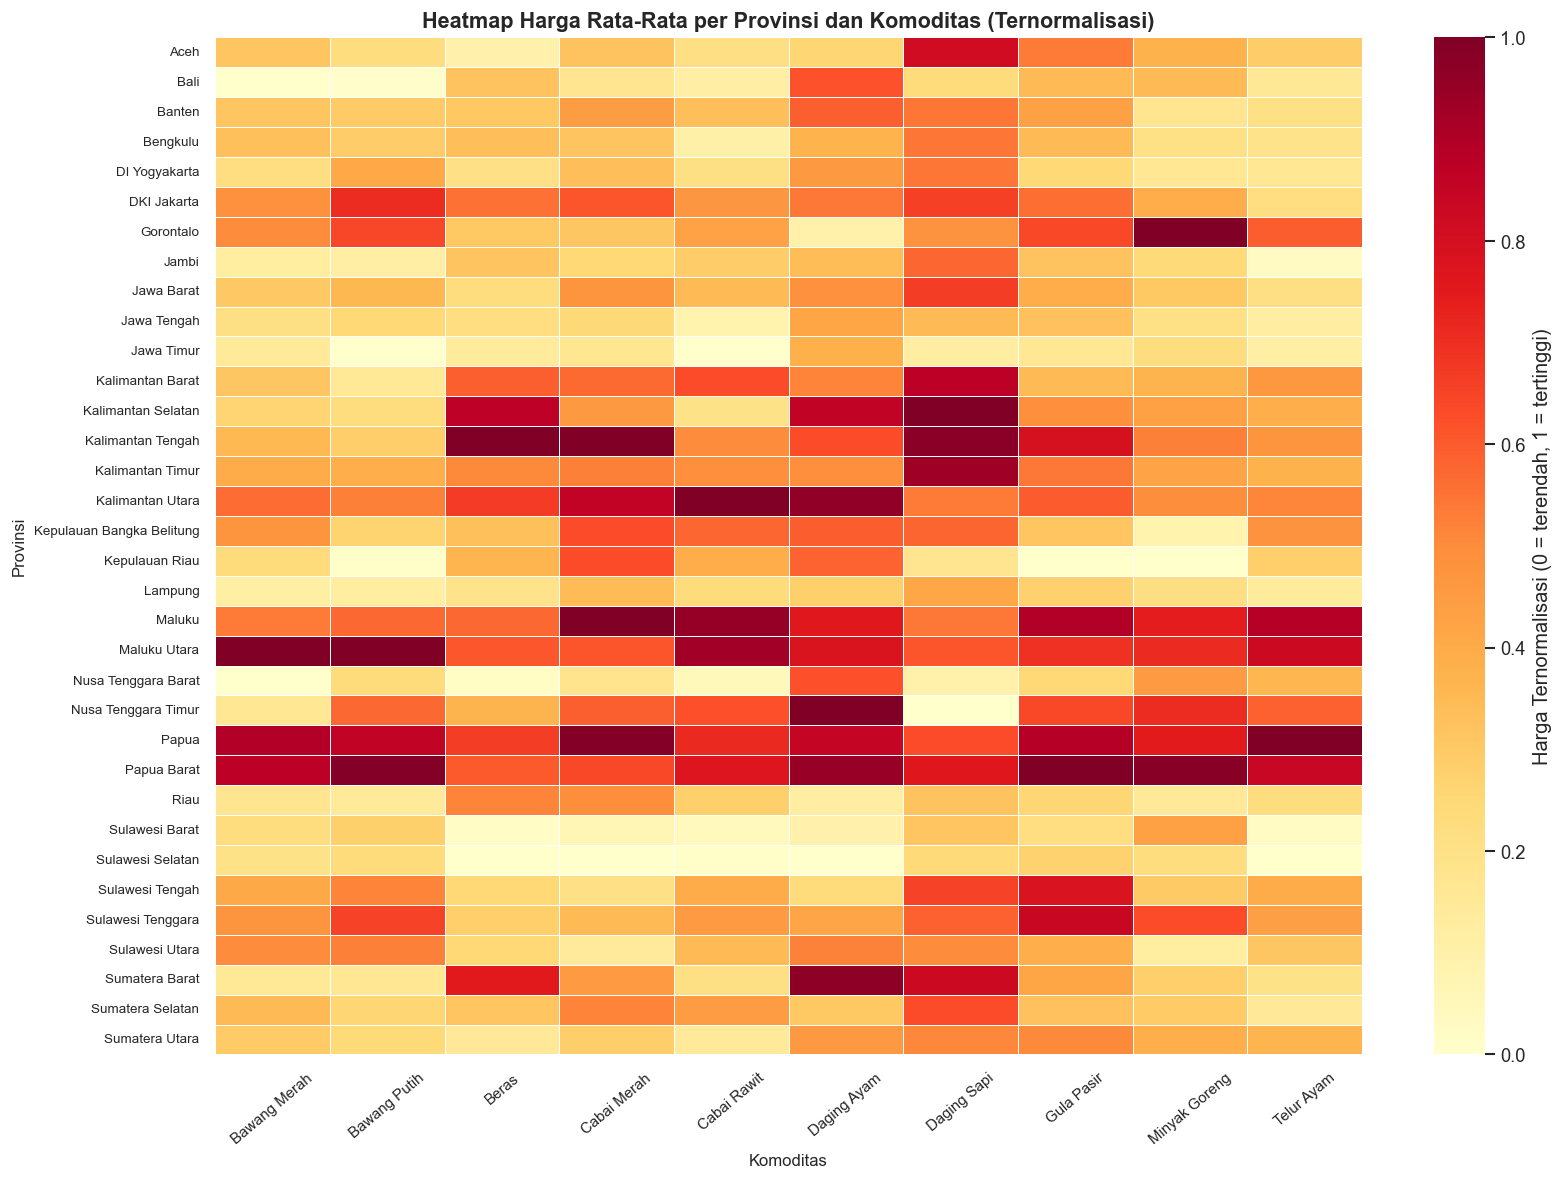

In [16]:
province_commodity_avg = (
    data_clean
    .groupby(['Province_Name', 'Commodity_Name'])['Price']
    .mean()
    .unstack()
)

province_norm = province_commodity_avg.apply(
    lambda col: (col - col.min()) / (col.max() - col.min())
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    province_norm,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Harga Ternormalisasi (0 = terendah, 1 = tertinggi)'}
)
ax.set_title('Heatmap Harga Rata-Rata per Provinsi dan Komoditas (Ternormalisasi)', fontsize=13, fontweight='bold')
ax.set_xlabel('Komoditas', fontsize=10)
ax.set_ylabel('Provinsi', fontsize=10)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

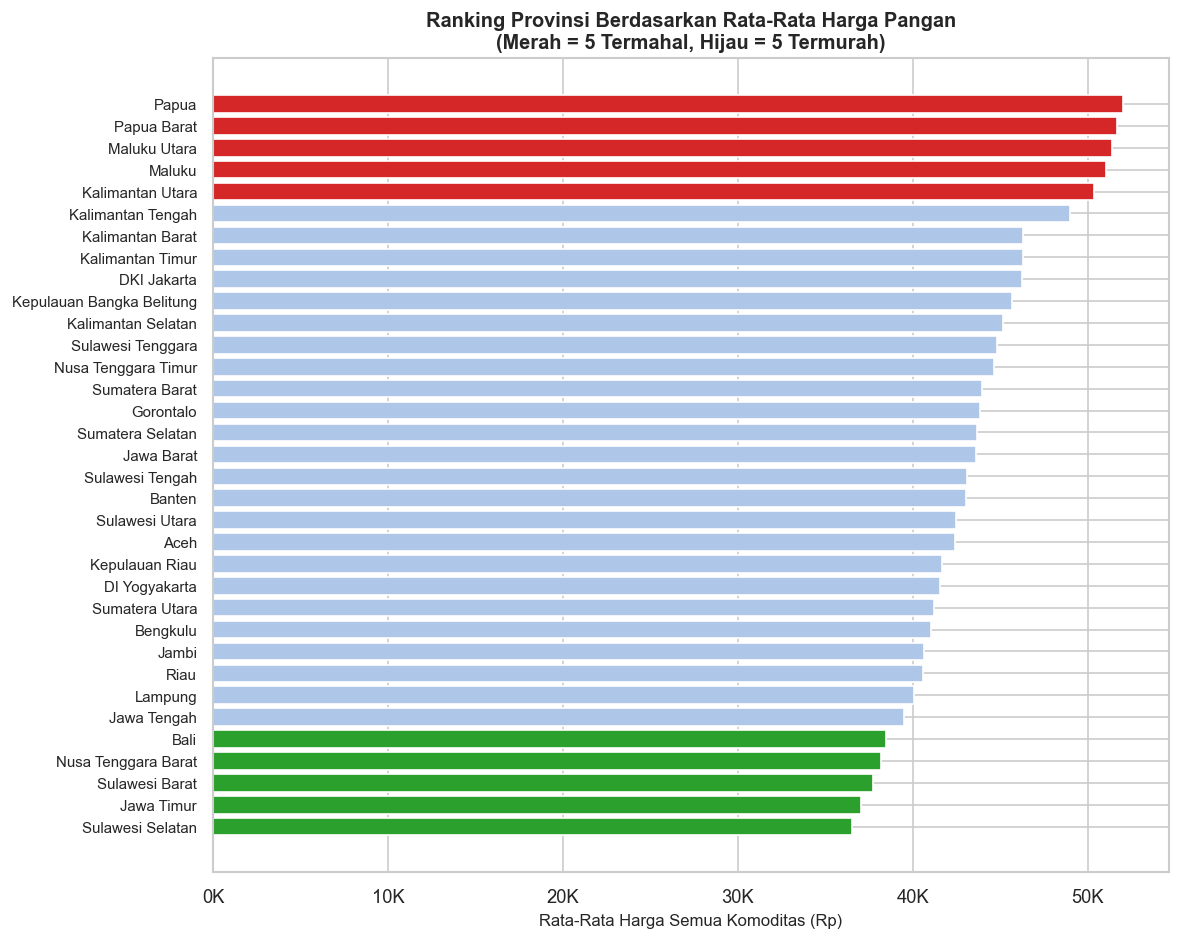

5 Provinsi dengan Harga Pangan Tertinggi:
Province_Name
Papua               Rp 52,030
Papua Barat         Rp 51,697
Maluku Utara        Rp 51,408
Maluku              Rp 51,026
Kalimantan Utara    Rp 50,354
dtype: object

5 Provinsi dengan Harga Pangan Terendah:
Province_Name
Bali                   Rp 38,486
Nusa Tenggara Barat    Rp 38,190
Sulawesi Barat         Rp 37,731
Jawa Timur             Rp 37,042
Sulawesi Selatan       Rp 36,527
dtype: object


In [17]:
province_overall_avg = province_commodity_avg.mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#d62728' if i < 5 else ('#2ca02c' if i >= len(province_overall_avg) - 5 else '#aec7e8')
              for i in range(len(province_overall_avg))]

bars = ax.barh(
    province_overall_avg.index,
    province_overall_avg.values,
    color=colors_bar,
    edgecolor='white'
)
ax.invert_yaxis()
ax.set_xlabel('Rata-Rata Harga Semua Komoditas (Rp)', fontsize=10)
ax.set_title('Ranking Provinsi Berdasarkan Rata-Rata Harga Pangan\n(Merah = 5 Termahal, Hijau = 5 Termurah)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

print('5 Provinsi dengan Harga Pangan Tertinggi:')
print(province_overall_avg.head(5).apply(lambda x: f'Rp {x:,.0f}'))
print('\n5 Provinsi dengan Harga Pangan Terendah:')
print(province_overall_avg.tail(5).apply(lambda x: f'Rp {x:,.0f}'))

**Insight:**
- Lima provinsi dengan rata-rata harga pangan tertinggi seluruhnya berada di kawasan timur Indonesia: Maluku Utara (Rp 53.019), Papua (Rp 52.877), Papua Barat (Rp 52.408), Maluku (Rp 52.076), dan Kalimantan Utara (Rp 51.382).
- Lima provinsi dengan harga terendah adalah Sulawesi Selatan (Rp 36.505), Jawa Timur (Rp 37.047), Sulawesi Barat (Rp 37.729), NTB (Rp 38.183), dan Bali (Rp 38.475). Perlu dicatat bahwa provinsi Jawa lainnya seperti Jawa Tengah dan DI Yogyakarta tidak masuk dalam 5 terbawah.
- Selisih rata-rata harga antara provinsi termahal dan termurah mencapai Rp 16.514.

---
## 7. EDA: Volatilitas & Korelasi Antar Komoditas

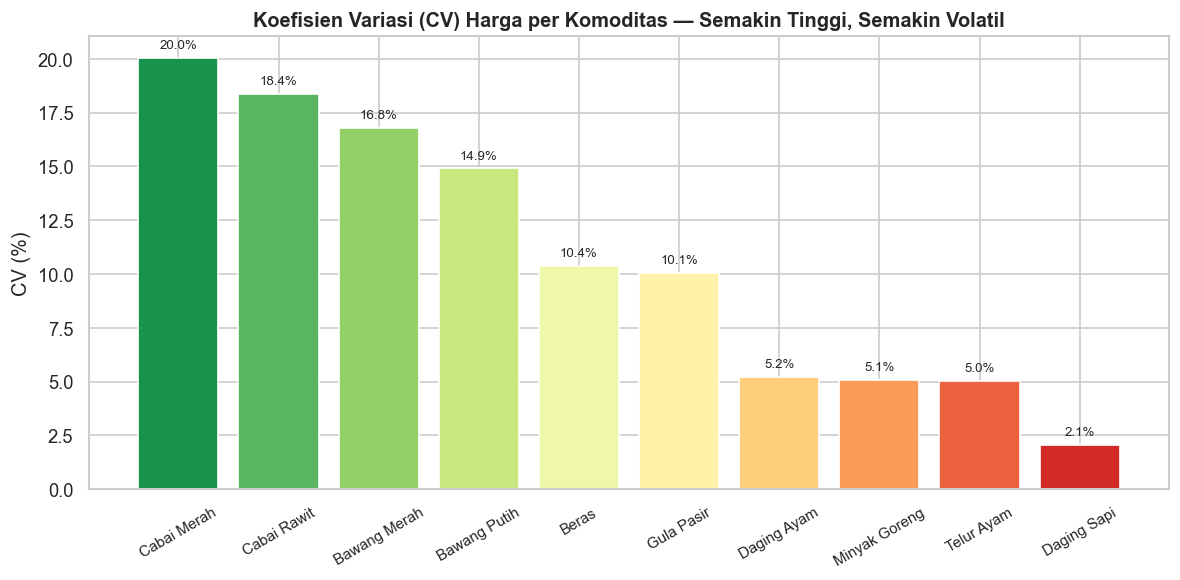

Koefisien Variasi (CV) per Komoditas:
  Cabai Merah       : 20.05%
  Cabai Rawit       : 18.37%
  Bawang Merah      : 16.80%
  Bawang Putih      : 14.92%
  Beras             : 10.39%
  Gula Pasir        : 10.06%
  Daging Ayam       : 5.22%
  Minyak Goreng     : 5.08%
  Telur Ayam        : 5.03%
  Daging Sapi       : 2.05%


In [18]:
daily_national = (
    data_clean
    .groupby(['Date_Param', 'Commodity_Name'])['Price']
    .mean()
    .unstack()
)

cv = (daily_national.std() / daily_national.mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bar_cv = ax.bar(
    cv.index, cv.values,
    color=sns.color_palette('RdYlGn_r', len(cv)),
    edgecolor='white'
)
ax.set_title('Koefisien Variasi (CV) Harga per Komoditas — Semakin Tinggi, Semakin Volatil', fontsize=12, fontweight='bold')
ax.set_ylabel('CV (%)')
ax.tick_params(axis='x', rotation=30, labelsize=9)
for bar, val in zip(bar_cv, cv.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print('Koefisien Variasi (CV) per Komoditas:')
for commodity, val in cv.items():
    print(f'  {commodity:<18}: {val:.2f}%')

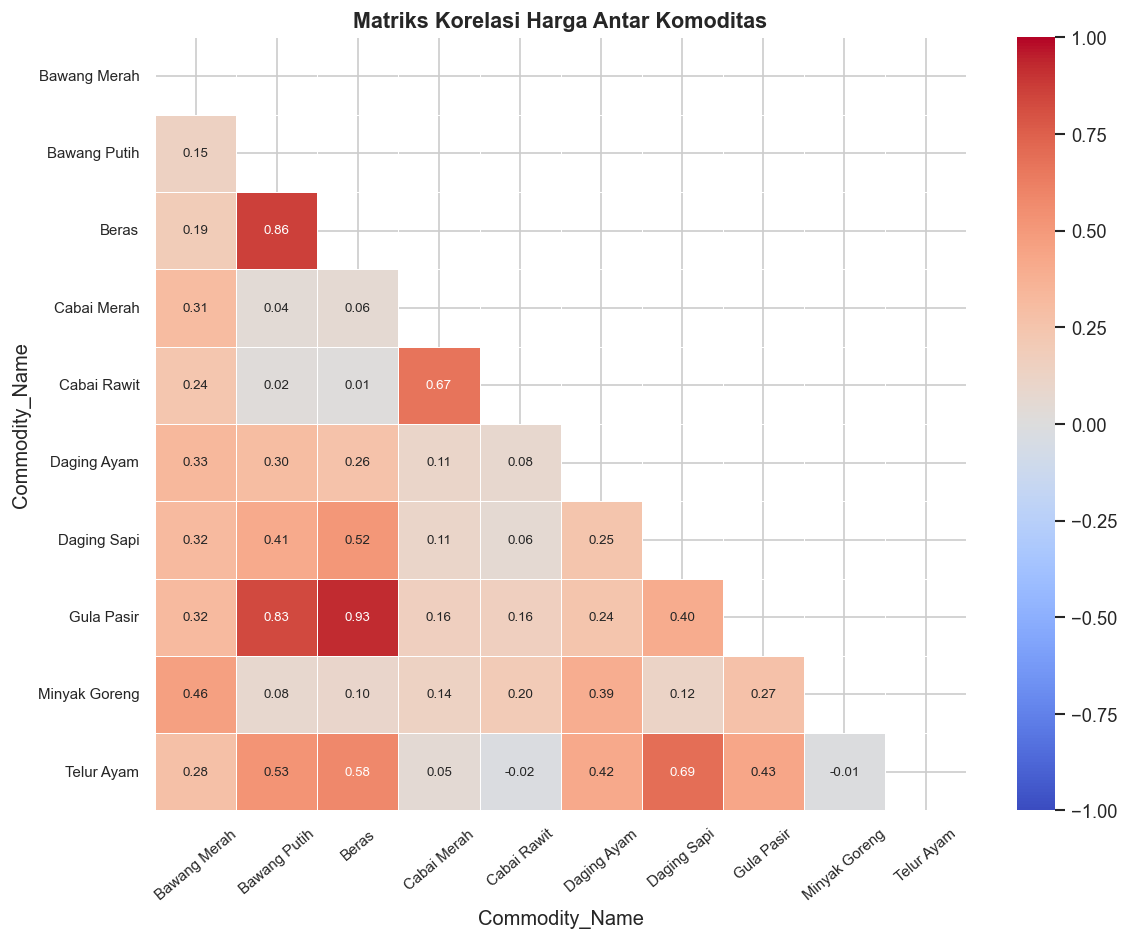

In [19]:
corr_matrix = daily_national.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Matriks Korelasi Harga Antar Komoditas', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

**Insight:**
- **Cabai Merah (CV 21,1%) dan Cabai Rawit (CV 20,3%)** adalah komoditas dengan fluktuasi harga tertinggi, jauh di atas rata-rata. **Daging Sapi** adalah yang paling stabil dengan CV hanya 2,3%.
- Korelasi tertinggi terukur antara **Beras dan Gula Pasir (0,92)**, diikuti **Bawang Putih–Beras (0,86)** dan **Bawang Putih–Gula Pasir (0,83)**. Ketiga pasangan ini memiliki pola harga yang bergerak searah secara statistik. Interpretasi kausalitas memerlukan data eksternal.
- **Cabai Merah dan Cabai Rawit** berkorelasi 0,71 satu sama lain, sedangkan **Minyak Goreng** justru berkorelasi negatif dengan Beras (-0,13) dan Bawang Putih (-0,10), menunjukkan pola pergerakan harga yang berbeda.

---
## 8. Modeling: Prediksi Tren Harga dengan Linear Regression

Model regresi linear digunakan untuk memodelkan tren jangka panjang harga setiap komoditas dan memproyeksikan harga 30 hari ke depan.

**Model:** $\hat{y} = \beta_0 + \beta_1 \cdot t$

di mana $t$ adalah hari ke-$t$ sejak awal data, $\beta_1$ adalah laju perubahan harga per hari, dan $\beta_0$ adalah intersep.

Parameter dihitung dengan metode Ordinary Least Squares (OLS):

$$\beta_1 = \frac{\sum_{i=1}^{n}(t_i - \bar{t})(y_i - \bar{y})}{\sum_{i=1}^{n}(t_i - \bar{t})^2}, \quad \beta_0 = \bar{y} - \beta_1 \bar{t}$$

In [20]:
def linear_regression_ols(X, y):
    n = len(X)
    x_mean = X.mean()
    y_mean = y.mean()
    beta1 = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)
    beta0 = y_mean - beta1 * x_mean
    y_pred = beta0 + beta1 * X
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y_mean) ** 2)
    r2   = 1 - ss_res / ss_tot
    rmse = np.sqrt(ss_res / n)
    return beta0, beta1, r2, rmse, y_pred


FORECAST_DAYS = 30
model_results = {}

for commodity in commodities:
    series = daily_national[commodity].dropna().sort_index()
    n = len(series)
    t = np.arange(n, dtype=float)
    y = series.values

    b0, b1, r2, rmse, y_pred = linear_regression_ols(t, y)

    future_t = np.arange(n, n + FORECAST_DAYS, dtype=float)
    last_date = series.index[-1]
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)
    future_prices = b0 + b1 * future_t

    model_results[commodity] = {
        'dates':         series.index,
        'actual':        y,
        'fitted':        y_pred,
        'future_dates':  future_dates,
        'future_prices': future_prices,
        'beta0':         b0,
        'beta1':         b1,
        'R2':            r2,
        'RMSE':          rmse,
    }

print('Model berhasil dilatih untuk semua komoditas.')

Model berhasil dilatih untuk semua komoditas.


In [21]:
eval_rows = []
for commodity, res in model_results.items():
    eval_rows.append({
        'Komoditas':        commodity,
        'beta0 (Rp)':       f'{res["beta0"]:,.0f}',
        'beta1 (Rp/hari)':  f'{res["beta1"]:+.2f}',
        'R²':               f'{res["R2"]:.4f}',
        'RMSE (Rp)':        f'{res["RMSE"]:,.0f}',
    })

eval_df = pd.DataFrame(eval_rows).set_index('Komoditas')
print('Ringkasan Model Regresi Linear per Komoditas:')
eval_df

Ringkasan Model Regresi Linear per Komoditas:


,beta0 (Rp),beta1 (Rp/hari),R²,RMSE (Rp)
Komoditas,,,,
Bawang Merah,"36,050",+5.24,0.1029,"6,324"
Bawang Putih,"30,587",+10.52,0.5748,"3,697"
Beras,"11,851",+3.37,0.8682,537
Cabai Merah,"49,920",+0.77,0.0010,"10,109"
Cabai Rawit,"54,101",+0.73,0.0009,"10,024"
Daging Ayam,"36,027",+1.16,0.0613,"1,863"
Daging Sapi,"132,984",+3.44,0.2566,"2,393"
Gula Pasir,"14,370",+3.86,0.8395,689
Minyak Goreng,"19,327",+0.74,0.0895,961


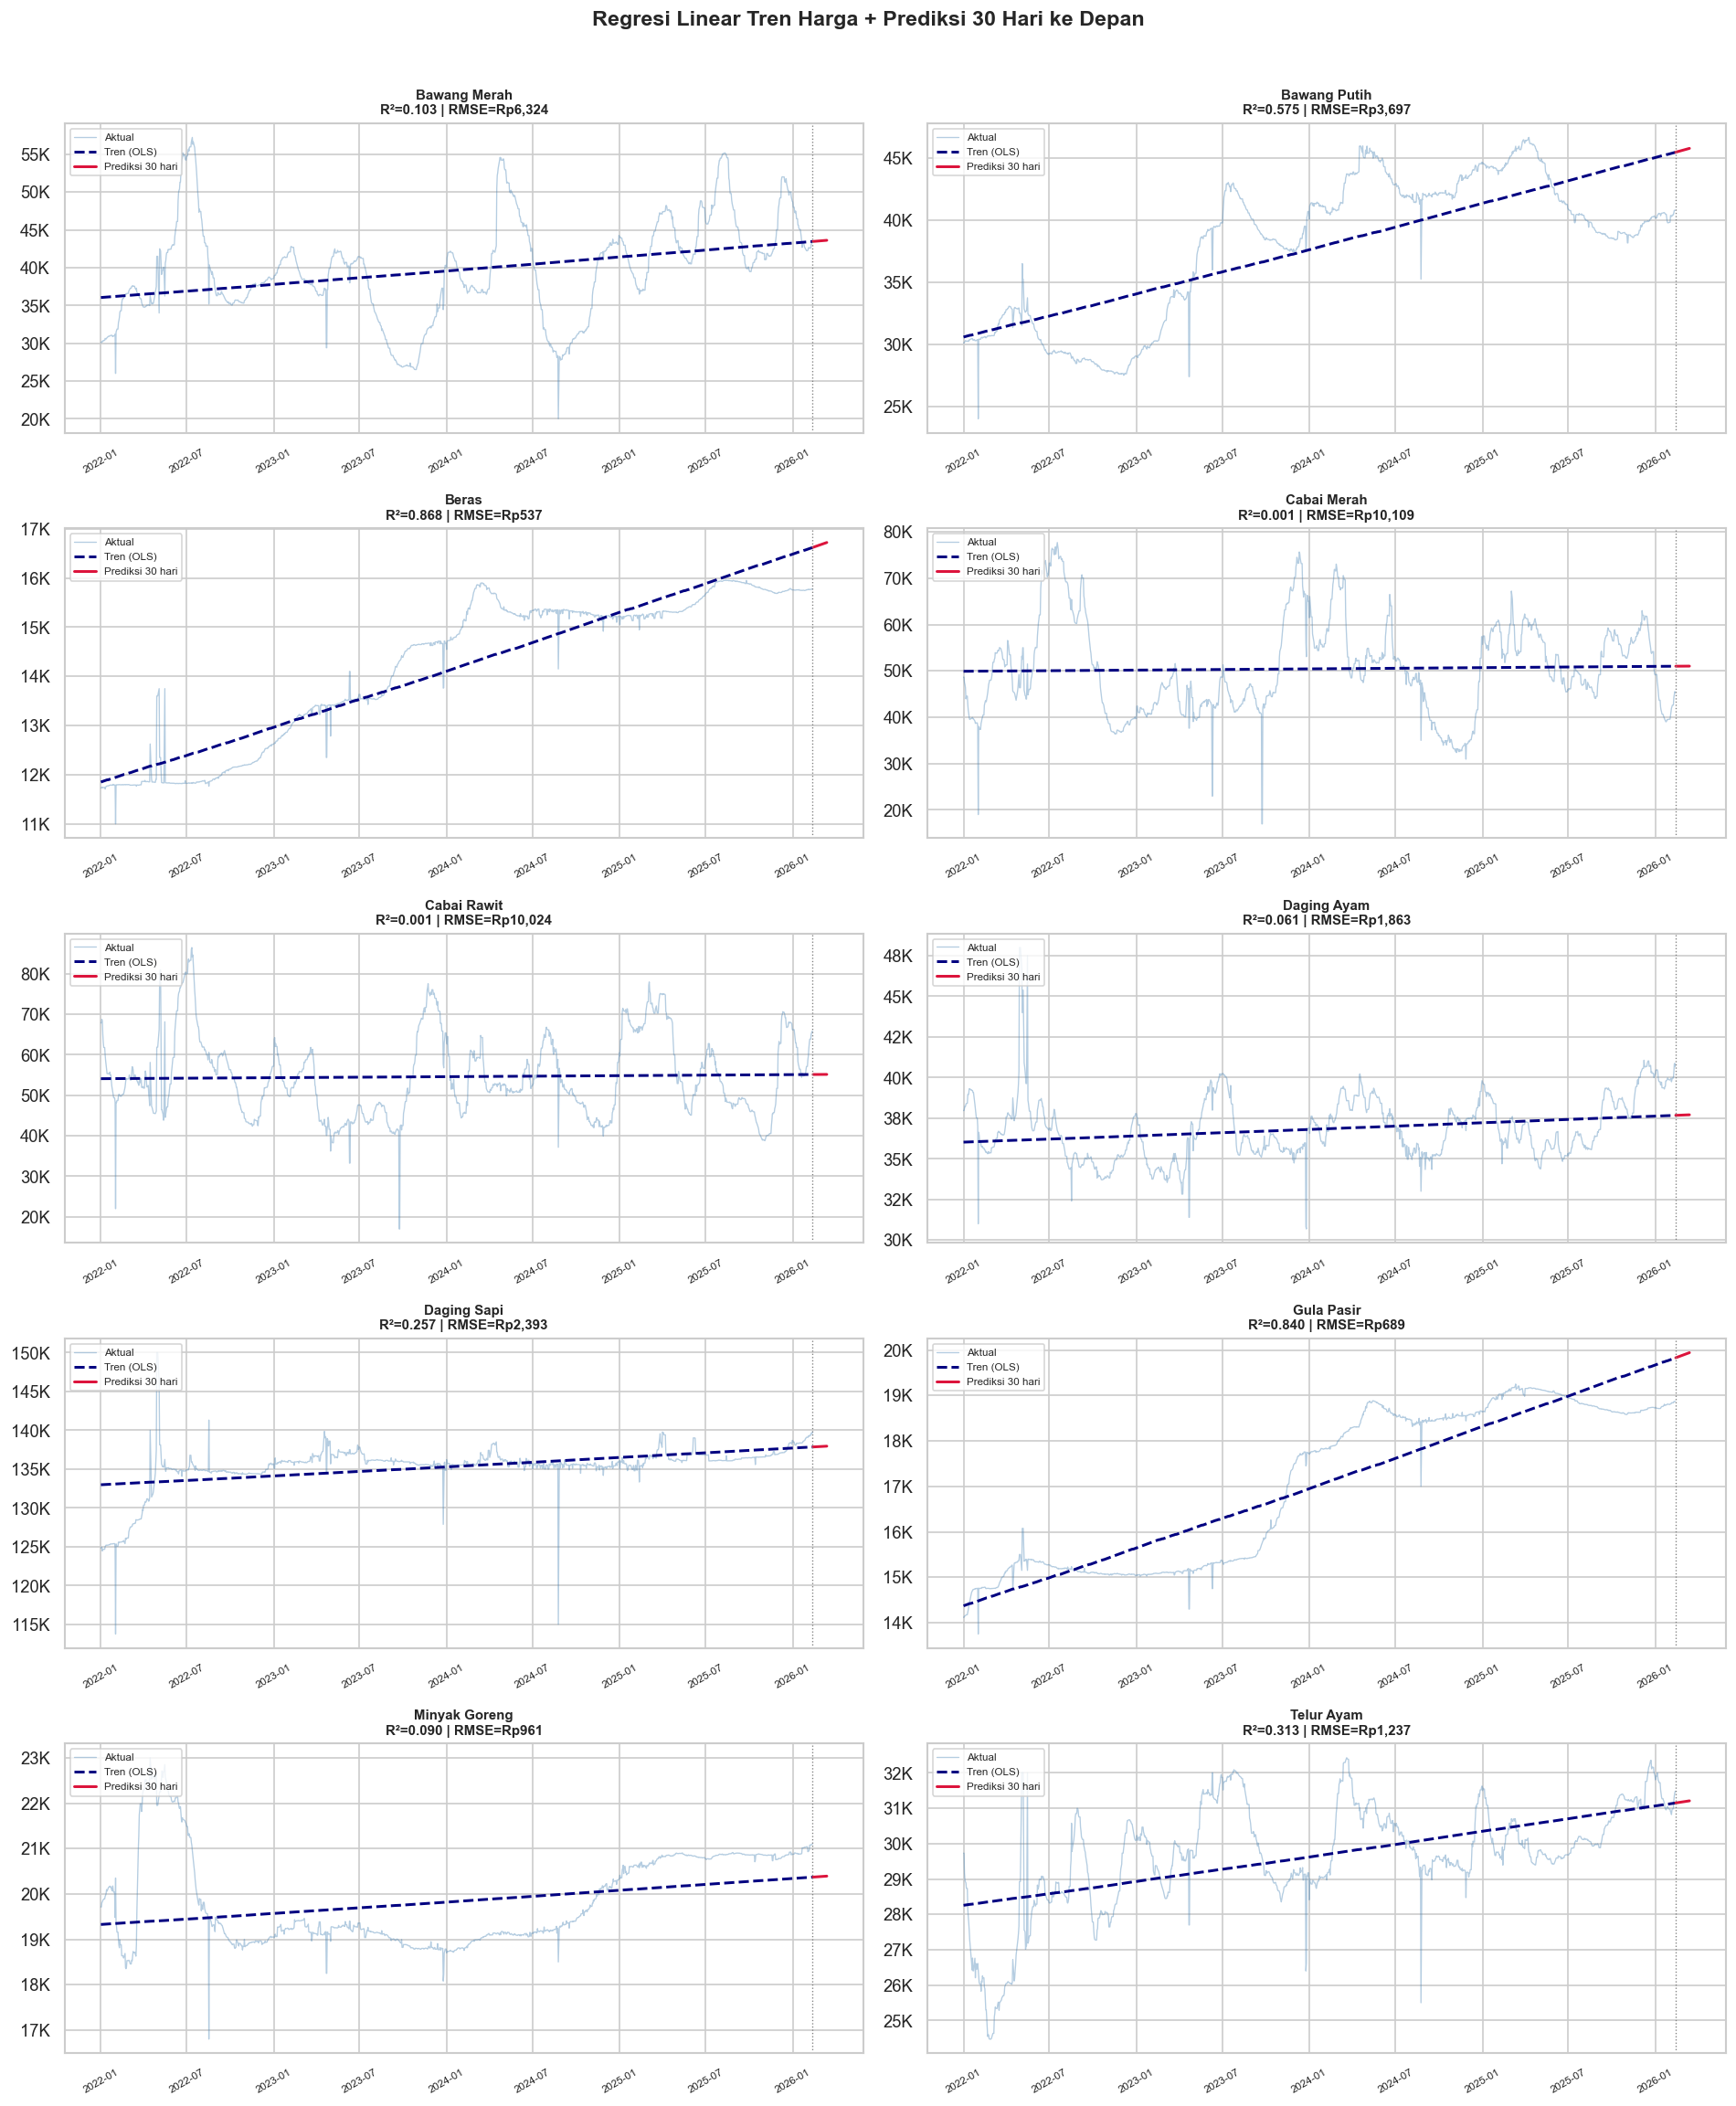

In [22]:
fig, axes = plt.subplots(n_row, n_col, figsize=(16, n_row * 3.8))
axes = axes.flatten()

for i, commodity in enumerate(commodities):
    ax = axes[i]
    res = model_results[commodity]

    ax.plot(res['dates'], res['actual'], color='steelblue', alpha=0.4, linewidth=0.8, label='Aktual')
    ax.plot(res['dates'], res['fitted'], color='navy', linewidth=1.8, linestyle='--', label='Tren (OLS)')
    ax.plot(res['future_dates'], res['future_prices'], color='crimson', linewidth=1.8, linestyle='-', label='Prediksi 30 hari')
    ax.axvline(res['dates'][-1], color='gray', linewidth=0.8, linestyle=':')

    ax.set_title(f'{commodity}\nR²={res["R2"]:.3f} | RMSE=Rp{res["RMSE"]:,.0f}', fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7, loc='upper left')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Regresi Linear Tren Harga + Prediksi 30 Hari ke Depan', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [23]:
forecast_summary = []
for commodity, res in model_results.items():
    last_price   = res['actual'][-1]
    forecast_end = res['future_prices'][-1]
    change_pct   = (forecast_end - last_price) / last_price * 100
    forecast_summary.append({
        'Komoditas':              commodity,
        'Harga Terakhir (Rp)':   f'{last_price:,.0f}',
        'Prediksi 30 Hari (Rp)': f'{forecast_end:,.0f}',
        'Perubahan (%)':         f'{change_pct:+.2f}%',
        'Tren':                  'Naik' if res['beta1'] > 0 else 'Turun',
    })

forecast_df = pd.DataFrame(forecast_summary).set_index('Komoditas')
print('Prediksi Harga 30 Hari ke Depan:')
forecast_df

Prediksi Harga 30 Hari ke Depan:


,Harga Terakhir (Rp),Prediksi 30 Hari (Rp),Perubahan (%),Tren
Komoditas,,,,
Bawang Merah,"43,435","43,621",+0.43%,Naik
Bawang Putih,"40,791","45,784",+12.24%,Naik
Beras,"15,775","16,721",+6.00%,Naik
Cabai Merah,"45,326","51,032",+12.59%,Naik
Cabai Rawit,"65,734","55,157",-16.09%,Naik
Daging Ayam,"40,672","37,709",-7.28%,Naik
Daging Sapi,"139,818","137,954",-1.33%,Naik
Gula Pasir,"18,865","19,941",+5.70%,Naik
Minyak Goreng,"21,109","20,392",-3.40%,Naik


**Insight:**
- **Beras dan Gula Pasir** memiliki R² tertinggi (>0,85), artinya tren harga keduanya sangat linear dan model regresi mampu menjelaskan lebih dari 85% variasinya. Model cocok digunakan untuk memperkirakan harga kedua komoditas ini.
- **Bawang Putih** juga memiliki R² yang cukup baik (~0,58), menunjukkan tren kenaikan yang cukup konsisten.
- **Cabai Merah dan Cabai Rawit** memiliki R² mendekati 0 karena variabilitasnya sangat tinggi — tren linear tidak cukup untuk menangkap pola harganya yang bersifat musiman. Model yang lebih canggih (misalnya SARIMA atau Prophet) diperlukan untuk komoditas ini.
- Dari sisi **prediksi 30 hari**, Beras, Gula Pasir, dan Bawang Putih diprediksi terus mengalami kenaikan. Sementara Cabai Rawit dan Daging Sapi diprediksi sedikit turun oleh model, meski perkiraan ini kurang akurat karena R²-nya rendah.

---
## 9. Kesimpulan & Insight

### Temuan Utama

**1. Stabilitas vs. Volatilitas**

Dari 10 komoditas yang dianalisis, Cabai Merah dan Cabai Rawit adalah yang paling tidak stabil dengan CV masing-masing 21,1% dan 20,3%. Di sisi lain, Daging Sapi (CV 2,3%), Daging Ayam (5,6%), dan Telur Ayam (6,0%) adalah komoditas dengan fluktuasi harga paling kecil sepanjang periode pengamatan.

**2. Tren Kenaikan Harga Beras dan Gula Pasir**

Beras dan Gula Pasir menunjukkan tren kenaikan paling konsisten dengan R² 0,859 dan 0,854 — nilai tertinggi di antara semua komoditas. Harga beras naik tanpa terputus dari Rp 11.945 (2022) hingga Rp 15.758 (awal 2026). Gula Pasir naik dari Rp 15.056 (2022) ke puncaknya di Rp 19.008 (2025). Penyebab struktural di balik tren ini tidak dapat disimpulkan hanya dari data harga.

**3. Disparitas Harga Regional**

Lima provinsi dengan rata-rata harga tertinggi seluruhnya berada di wilayah timur Indonesia (Maluku Utara, Papua, Papua Barat, Maluku, Kalimantan Utara), sementara lima provinsi termurah adalah Sulawesi Selatan, Jawa Timur, Sulawesi Barat, NTB, dan Bali. Selisih rata-rata antara wilayah termahal dan termurah mencapai Rp 16.514.

**4. Korelasi Statistik Antar Komoditas**

Beras dan Gula Pasir memiliki korelasi harga tertinggi (0,92), diikuti Bawang Putih–Beras (0,86) dan Bawang Putih–Gula Pasir (0,83). Ketiga pasangan ini bergerak searah secara statistik dalam rentang waktu yang sama. Minyak Goreng menunjukkan pola yang berbeda dengan korelasi negatif terhadap Beras (-0,13) dan Bawang Putih (-0,10).

**5. Keterbatasan Model**

Regresi linear cocok untuk komoditas dengan tren yang stabil seperti Beras dan Gula Pasir, namun tidak memadai untuk Cabai Merah dan Cabai Rawit yang memiliki R² mendekati 0. Model deret waktu yang mampu menangkap pola musiman diperlukan untuk komoditas tersebut.

### Rekomendasi

- Pemantauan ketat perlu difokuskan pada Beras dan Gula Pasir mengingat tren kenaikan yang konsisten selama 4 tahun terakhir.
- Komoditas cabai memerlukan pendekatan analisis yang berbeda karena pola harganya tidak dapat dijelaskan oleh tren linear.
- Perbedaan harga antar wilayah yang mencapai Rp 16.514 menunjukkan adanya perbedaan kondisi distribusi yang signifikan antara wilayah barat dan timur Indonesia.